# Datathon Passos Mágicos — Modelo Preditivo de Risco de Defasagem (Q9)

**Objetivo:** construir um modelo que estime a probabilidade de um aluno
entrar em risco de defasagem (nível abaixo do ideal) no ano seguinte, com
base nos indicadores do ano corrente.

**Etapas:**
1. Feature engineering
2. Separação treino/teste
3. Modelagem preditiva
4. Avaliação dos resultados

Fonte: `pede_unificado_wide.csv` (gerado no script de limpeza/unificação).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 1. Carregar dados e definir o alvo (target)

O alvo é: **o aluno entra em risco de defasagem no ano seguinte?**

Definição operacional: `DEFASAGEM_{ano+1} < 0` (ou seja, a Fase do aluno ficou abaixo da Fase Ideal). Usamos os indicadores do ano corrente como features para prever essa condição no ano seguinte -- é o cenário real de uso: identificar risco *antes* que ele se concretize.

Construímos duas transições disponíveis na base (2022→2023 e 2023→2024) e empilhamos como observações independentes, o que aumenta o volume de dados de treino.

In [2]:
wide = pd.read_csv("/mnt/user-data/outputs/pede_unificado_wide.csv")
print("Alunos únicos:", wide.shape[0])
wide.head(3)


Alunos únicos: 1874


,RA,NOME,GENERO,ANO_INGRESSO,CF_2022,CG_2022,CT_2022,DEFASAGEM_2022,DEFASAGEM_2023,DEFASAGEM_2024,DESTAQUE_IDA_2022,DESTAQUE_IEG_2022,DESTAQUE_IPV_2022,ESCOLA_2024,FASE_2022,FASE_2023,FASE_2024,FASE_IDEAL_2022,FASE_IDEAL_2023,FASE_IDEAL_2024,IAA_2022,IAA_2023,IAA_2024,IAN_2022,IAN_2023,IAN_2024,IDA_2022,IDA_2023,IDA_2024,IDADE_2022,IDADE_2023,IDADE_2024,IEG_2022,IEG_2023,IEG_2024,INDE_2022,INDE_2023,INDE_2024,INDICADO_BOLSA_2022,INSTITUICAO_ENSINO_2022,INSTITUICAO_ENSINO_2023,INSTITUICAO_ENSINO_2024,IPP_2023,IPP_2024,IPS_2022,IPS_2023,IPS_2024,IPV_2022,IPV_2023,IPV_2024,NOTA_ING_2022,NOTA_ING_2023,NOTA_ING_2024,NOTA_MAT_2022,NOTA_MAT_2023,NOTA_MAT_2024,NOTA_PORT_2022,NOTA_PORT_2023,NOTA_PORT_2024,PEDRA_2022,PEDRA_2023,PEDRA_2024,PONTO_VIRADA_2022,QTDE_AVAL_2022,QTDE_AVAL_2023,QTDE_AVAL_2024,REC_PSICO_2022,STATUS_ATIVO_2024,TURMA_2022,TURMA_2023,TURMA_2024
0,RA-1,Aluno-1,Feminino,2016,18.0,753.0,10.0,-1.0,0.0,NaN,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,7.0,FASE 8,NaN,Fase 8 (Universitários),Fase 8 (Universitários),NaN,8.3,NaN,NaN,5.0,10.0,NaN,4.0,NaN,NaN,19.0,NaN,NaN,4.1,NaN,NaN,5.783,NaN,NaN,True,Escola Pública,Privada *Parcerias com Bolsa 100%,NaN,NaN,NaN,5.6,NaN,NaN,7.278,NaN,NaN,6.0,NaN,NaN,2.7,NaN,NaN,3.5,NaN,NaN,Quartzo,NaN,NaN,False,4.0,NaN,NaN,Requer avaliação,NaN,A,8E,NaN
1,RA-1,Aluno-1,Feminino,2021,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,Universidade Santo Amaro (UNISA),NaN,NaN,8E,NaN,NaN,Fase 8 (Universitários),NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,21.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Privada *Parcerias com Bolsa 100%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Cursando,NaN,NaN,8E
2,RA-10,Aluno-10,Feminino,2021,17.0,752.0,9.0,-1.0,NaN,NaN,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,7.0,NaN,NaN,Fase 8 (Universitários),NaN,NaN,8.3,NaN,NaN,5.0,NaN,NaN,4.1,NaN,NaN,18.0,NaN,NaN,5.2,NaN,NaN,5.784,NaN,NaN,False,Escola Pública,NaN,NaN,NaN,NaN,5.0,NaN,NaN,7.056,NaN,NaN,6.4,NaN,NaN,3.3,NaN,NaN,2.6,NaN,NaN,Quartzo,NaN,NaN,False,4.0,NaN,NaN,Requer avaliação,NaN,A,NaN,NaN


In [3]:
FEATURES_BASE = ["IAN", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "INDE",
                  "DEFASAGEM", "FASE", "PEDRA", "IDADE"]

def montar_transicao(df, ano_ini, ano_fim):
    cols_ini = {f"{f}_{ano_ini}": f for f in FEATURES_BASE if f"{f}_{ano_ini}" in df.columns}
    col_target = f"DEFASAGEM_{ano_fim}"
    if col_target not in df.columns:
        return None

    sub = df[["RA", "GENERO", "ANO_INGRESSO"] + list(cols_ini.keys()) + [col_target]].copy()
    sub = sub.rename(columns=cols_ini)
    sub["TARGET_RISCO"] = (sub[col_target] < 0).astype(int)
    sub["ANO_REFERENCIA"] = ano_ini
    sub = sub.drop(columns=[col_target])
    return sub

t1 = montar_transicao(wide, 2022, 2023)
t2 = montar_transicao(wide, 2023, 2024)

dataset = pd.concat([t1, t2], ignore_index=True)
dataset = dataset.dropna(subset=["TARGET_RISCO"])
print("Linhas no dataset de modelagem:", len(dataset))
print("Taxa de risco (classe positiva):", dataset["TARGET_RISCO"].mean().round(3))
dataset.head()


Linhas no dataset de modelagem: 3748
Taxa de risco (classe positiva): 0.29


,RA,GENERO,ANO_INGRESSO,IAN,IDA,IEG,IAA,IPS,IPV,INDE,DEFASAGEM,FASE,PEDRA,IDADE,TARGET_RISCO,ANO_REFERENCIA,IPP
0,RA-1,Feminino,2016,5.0,4.0,4.1,8.3,5.6,7.278,5.783,-1.0,7.0,Quartzo,19.0,0,2022,NaN
1,RA-1,Feminino,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2022,NaN
2,RA-10,Feminino,2021,5.0,4.1,5.2,8.3,5.0,7.056,5.784,-1.0,7.0,Quartzo,18.0,0,2022,NaN
3,RA-100,Feminino,2019,10.0,7.6,7.8,8.8,5.0,7.250,7.618,1.0,4.0,Ametista,13.0,0,2022,NaN
4,RA-1000,Feminino,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2022,NaN


## 2. Feature engineering

- Tratamos `PEDRA` e `GENERO` como categóricas (one-hot).
- Indicadores numéricos (`IAN`, `IDA`, `IEG`, `IAA`, `IPS`, `IPP`, `IPV`, `INDE`, `DEFASAGEM`, `IDADE`) entram direto, com imputação de faltantes pela mediana (IPP e IPS têm bastante ausência em 2022, por exemplo).
- Criamos uma feature derivada: `GAP_ENGAJAMENTO_APRENDIZAGEM` = IEG - IDA, que captura desalinhamento entre esforço percebido e resultado.
- `TEMPO_NA_PM` = ano de referência - ano de ingresso (proxy do tempo de programa).

In [4]:
dataset["GAP_ENGAJAMENTO_APRENDIZAGEM"] = dataset["IEG"] - dataset["IDA"]
dataset["TEMPO_NA_PM"] = dataset["ANO_REFERENCIA"] - dataset["ANO_INGRESSO"]

FEATURES_NUMERICAS = ["IAN", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "INDE",
                       "DEFASAGEM", "IDADE", "GAP_ENGAJAMENTO_APRENDIZAGEM",
                       "TEMPO_NA_PM"]
FEATURES_CATEGORICAS = ["PEDRA", "GENERO"]

X = dataset[FEATURES_NUMERICAS + FEATURES_CATEGORICAS]
y = dataset["TARGET_RISCO"]

print(X.isna().sum())


IAN                             1874
IDA                             1951
IEG                             1950
IAA                             1937
IPS                             1943
IPP                             2810
IPV                             1950
INDE                            1957
DEFASAGEM                       1874
IDADE                           2273
GAP_ENGAJAMENTO_APRENDIZAGEM    1951
TEMPO_NA_PM                        0
PEDRA                           1957
GENERO                             0
dtype: int64


## 3. Separação treino/teste

Split estratificado (mantém a proporção da classe de risco em treino e teste) com 25% para teste.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Treino:", X_train.shape, " Teste:", X_test.shape)
print("Taxa de risco - treino:", y_train.mean().round(3), " teste:", y_test.mean().round(3))


Treino: (2811, 14)  Teste: (937, 14)
Taxa de risco - treino: 0.29  teste: 0.289


## 4. Pipeline de pré-processamento + modelagem

Comparamos dois modelos:
- **Regressão Logística** (baseline interpretável)
- **Random Forest** (captura não-linearidades e interações entre indicadores)

In [6]:
preprocessador = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), FEATURES_NUMERICAS),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), FEATURES_CATEGORICAS),
])

modelo_logreg = Pipeline([
    ("prep", preprocessador),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

modelo_rf = Pipeline([
    ("prep", preprocessador),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=10,
        class_weight="balanced", random_state=42
    )),
])

modelo_logreg.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)
print("Modelos treinados.")


Modelos treinados.


## 5. Avaliação dos resultados


=== Regressão Logística ===
              precision    recall  f1-score   support

   Sem risco       0.84      0.55      0.67       666
       Risco       0.40      0.74      0.52       271

    accuracy                           0.61       937
   macro avg       0.62      0.65      0.59       937
weighted avg       0.71      0.61      0.62       937

AUC-ROC: 0.658
F1 (classe risco): 0.521


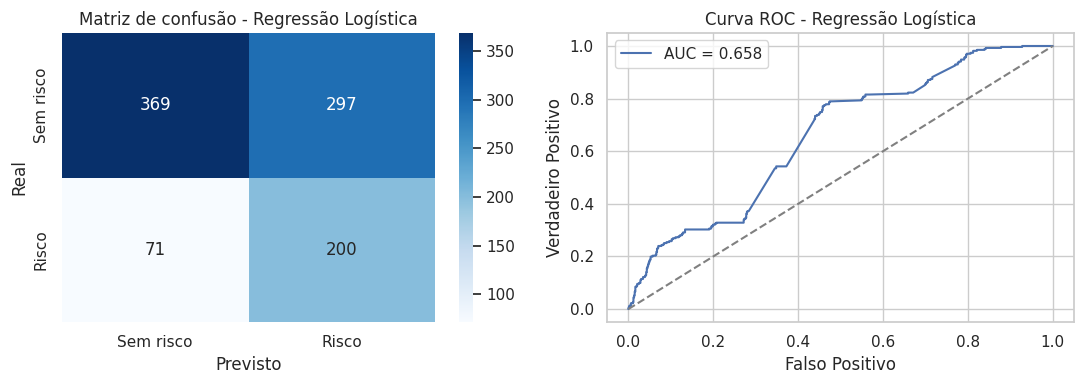


=== Random Forest ===
              precision    recall  f1-score   support

   Sem risco       0.87      0.68      0.76       666
       Risco       0.49      0.75      0.59       271

    accuracy                           0.70       937
   macro avg       0.68      0.71      0.68       937
weighted avg       0.76      0.70      0.71       937

AUC-ROC: 0.789
F1 (classe risco): 0.591


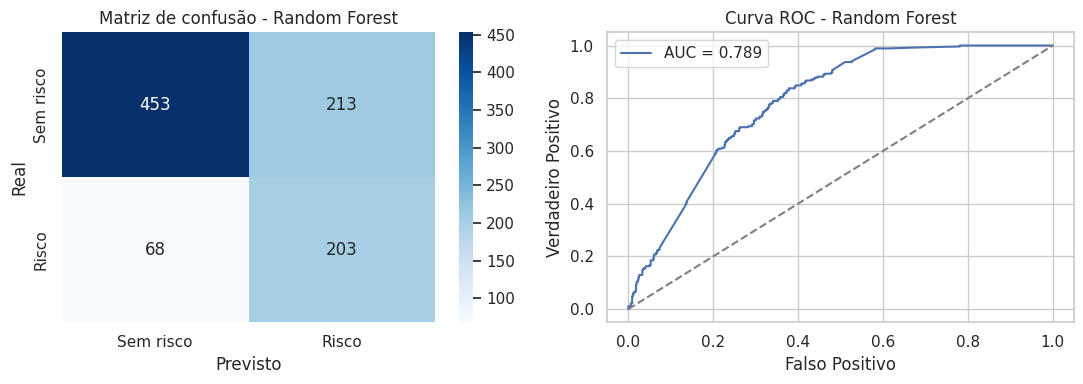

In [7]:
def avaliar(modelo, nome):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    print(f"\n=== {nome} ===")
    print(classification_report(y_test, y_pred, target_names=["Sem risco", "Risco"]))
    print("AUC-ROC:", round(roc_auc_score(y_test, y_proba), 3))
    print("F1 (classe risco):", round(f1_score(y_test, y_pred), 3))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=["Sem risco", "Risco"], yticklabels=["Sem risco", "Risco"])
    axes[0].set_title(f"Matriz de confusão - {nome}")
    axes[0].set_xlabel("Previsto")
    axes[0].set_ylabel("Real")

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_title(f"Curva ROC - {nome}")
    axes[1].set_xlabel("Falso Positivo")
    axes[1].set_ylabel("Verdadeiro Positivo")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    return y_proba

proba_logreg = avaliar(modelo_logreg, "Regressão Logística")
proba_rf = avaliar(modelo_rf, "Random Forest")


### Importância das variáveis (Random Forest)

Mostra quais indicadores mais pesam na decisão do modelo -- útil para explicar o modelo para a equipe pedagógica da Passos Mágicos.

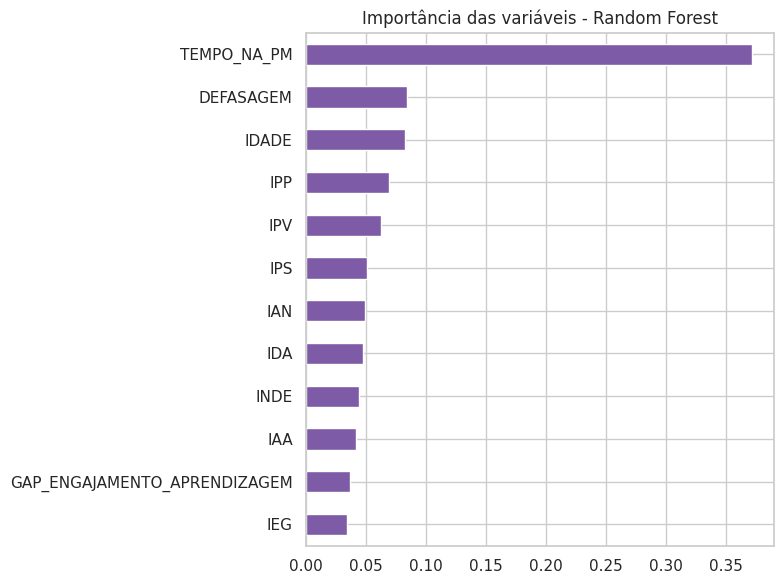

TEMPO_NA_PM                     0.371776
DEFASAGEM                       0.084009
IDADE                           0.082334
IPP                             0.068882
IPV                             0.062763
IPS                             0.051143
IAN                             0.049356
IDA                             0.047985
INDE                            0.043846
IAA                             0.041512
GAP_ENGAJAMENTO_APRENDIZAGEM    0.036758
IEG                             0.034574
dtype: float64

In [8]:
prep_fit = modelo_rf.named_steps["prep"]
nomes_num = FEATURES_NUMERICAS
nomes_cat = list(prep_fit.named_transformers_["cat"]["onehot"].get_feature_names_out(FEATURES_CATEGORICAS))
nomes_todas = nomes_num + nomes_cat

importancias = pd.Series(
    modelo_rf.named_steps["clf"].feature_importances_, index=nomes_todas
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importancias.head(12).plot(kind="barh", ax=ax, color="#7d5ba6")
ax.invert_yaxis()
ax.set_title("Importância das variáveis - Random Forest")
plt.tight_layout()
plt.show()

importancias.head(12)


## 6. Escolha do modelo e exportação

Escolhemos o modelo com melhor equilíbrio entre recall da classe de risco (não deixar passar aluno em risco) e AUC. Ajuste o `random_state`/modelo conforme o resultado obtido acima. Exportamos o pipeline treinado (pré-processamento + modelo) para uso no app Streamlit.

In [9]:
import joblib

MODELO_ESCOLHIDO = modelo_rf  # ajuste para modelo_logreg se preferir o baseline

joblib.dump(MODELO_ESCOLHIDO, "/mnt/user-data/outputs/modelo_risco_defasagem.pkl")
print("Modelo salvo em /mnt/user-data/outputs/modelo_risco_defasagem.pkl")

# Também salvamos a lista de features esperadas, para o app Streamlit montar o formulário
import json
schema = {"numericas": FEATURES_NUMERICAS, "categoricas": FEATURES_CATEGORICAS}
with open("/mnt/user-data/outputs/schema_features.json", "w") as f:
    json.dump(schema, f, ensure_ascii=False, indent=2)


Modelo salvo em /mnt/user-data/outputs/modelo_risco_defasagem.pkl


## 7. Limitações e próximos passos

- O `PONTO_VIRADA` (2023/2024) está ausente na base original, então não entrou como feature -- poderia ser um preditor forte se disponível.
- `IPP` e `IPS` têm alta taxa de ausência em 2022, o que reduz a robustez da imputação nesses casos.
- Apenas duas transições de ano estão disponíveis (2022→23, 2023→24); mais anos de histórico tenderiam a melhorar a generalização do modelo.
- Próximo passo natural: threshold de decisão ajustável (em vez de 0.5) para priorizar recall na classe de risco, dado o custo de um falso negativo (aluno em risco não identificado) ser maior que um falso positivo.